In [204]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
import os
import joblib

In [205]:
df = pd.read_csv('../datasets/data_compramostucoche.csv', sep=';', encoding='utf-8')
df.head()

,marca_nombre,marca_id,version_id_catalogo,titulo_anuncio,registro,km,cambio,combustible,cv,precio
0,Kia,425,3457.0,Kia cee'd 1.6 CRDi,06/2014,17222,Manual,Diésel,128,12599
1,Kia,425,3554.0,Kia Sorento 1.6 TGDI Plug-in Hybrid,04/2024,32462,Automático,Híbrido,265,40999
2,Peugeot,670,6159.0,Peugeot 3008 2.0 Blue-HDi,07/2018,78068,Manual,Diésel,150,17299
3,Mercedes-Benz,570,NaN,Mercedes-Benz Clase GLA GLA 250e,02/2024,19060,Automático,Híbrido,218,39999
4,Citroen,190,1551.0,Citroen C4 Cactus 1.6 Blue-HDi,10/2016,94982,Manual,Diésel,100,9399


In [206]:
df = df.rename(columns={
    'marca_nombre': 'make',
    'km': 'kms',
})

In [207]:
df.isnull().sum()

make                     0
marca_id                 0
version_id_catalogo    418
titulo_anuncio           0
registro                 0
kms                      0
cambio                   0
combustible              0
cv                       0
precio                   0
dtype: int64

In [208]:
data_null = df[df['version_id_catalogo'].isnull()]

data_null['make'].value_counts()

make
Mercedes-Benz     179
BMW                93
Seat               53
Citroen            50
Ford                9
Audi                7
Mazda               5
Cupra               3
Renault             2
Land Rover          2
Peugeot             2
Suzuki              1
Toyota              1
DS Automobiles      1
Volkswagen          1
Hyundai             1
MG                  1
Ssangyong           1
Fiat                1
Opel                1
Kia                 1
Jeep                1
Nissan              1
Mitsubishi          1
Name: count, dtype: int64

In [209]:
df_modelos = pd.read_csv('../datasets/seed_modelos.csv', sep=';', encoding='utf-8')
df_versiones = pd.read_csv('../datasets/seed_versiones.csv', sep=';', encoding='utf-8')
df_marcas = pd.read_csv('../datasets/seed_marcas.csv', sep=';', encoding='utf-8')

In [210]:
df_catalogo_completo = df_versiones.merge(df_modelos, on='modelo_id')
df_catalogo_completo = df_catalogo_completo.merge(df_marcas, on='marca_id')
df_catalogo_completo

,version_id,modelo_id,clave_motor,nombre_completo,id_web,nombre_modelo,marca_id,nombre_marca
0,1,1,1.4 Turbo,124 Spider 1.4 Turbo,124 Spider,124 Spider,20,Abarth
1,2,1,GT,124 Spider GT,124 Spider,124 Spider,20,Abarth
2,3,2,1.4 Turbo,500 1.4 Turbo,500,500,20,Abarth
3,4,3,electric drive 114 kW,500e electric drive 114 kW,500e,500e,20,Abarth
4,5,4,electric drive 114 kW,500e Cabrio electric drive 114 kW,500e Cabrio,500e Cabrio,20,Abarth
...,...,...,...,...,...,...,...,...
8554,8555,1524,Single Motor 310 kW,7X Single Motor 310 kW,7X,7X,929,Zeekr
8555,8556,1525,electric drive 200 kW,001 electric drive 200 kW,001,001,929,Zeekr
8556,8557,1525,electric drive 400 kW,001 electric drive 400 kW,001,001,929,Zeekr
8557,8558,1526,electric drive 200 kW,X electric drive 200 kW,X,X,929,Zeekr


In [211]:
df_catalogo_completo.rename(columns={
    'version_id': 'version_id_catalogo'
})

,version_id_catalogo,modelo_id,clave_motor,nombre_completo,id_web,nombre_modelo,marca_id,nombre_marca
0,1,1,1.4 Turbo,124 Spider 1.4 Turbo,124 Spider,124 Spider,20,Abarth
1,2,1,GT,124 Spider GT,124 Spider,124 Spider,20,Abarth
2,3,2,1.4 Turbo,500 1.4 Turbo,500,500,20,Abarth
3,4,3,electric drive 114 kW,500e electric drive 114 kW,500e,500e,20,Abarth
4,5,4,electric drive 114 kW,500e Cabrio electric drive 114 kW,500e Cabrio,500e Cabrio,20,Abarth
...,...,...,...,...,...,...,...,...
8554,8555,1524,Single Motor 310 kW,7X Single Motor 310 kW,7X,7X,929,Zeekr
8555,8556,1525,electric drive 200 kW,001 electric drive 200 kW,001,001,929,Zeekr
8556,8557,1525,electric drive 400 kW,001 electric drive 400 kW,001,001,929,Zeekr
8557,8558,1526,electric drive 200 kW,X electric drive 200 kW,X,X,929,Zeekr


In [212]:
df_catalogo_completo['titulo_anuncio'] = df_catalogo_completo['nombre_marca'] + ' ' + df_catalogo_completo['nombre_modelo'] + ' ' + df_catalogo_completo['clave_motor']

In [213]:
df_catalogo_completo['titulo_anuncio'] = df_catalogo_completo['titulo_anuncio'].str.lower()
df['titulo_anuncio'] = df['titulo_anuncio'].str.lower()

In [214]:
df_catalogo_completo

,version_id,modelo_id,clave_motor,nombre_completo,id_web,nombre_modelo,marca_id,nombre_marca,titulo_anuncio
0,1,1,1.4 Turbo,124 Spider 1.4 Turbo,124 Spider,124 Spider,20,Abarth,abarth 124 spider 1.4 turbo
1,2,1,GT,124 Spider GT,124 Spider,124 Spider,20,Abarth,abarth 124 spider gt
2,3,2,1.4 Turbo,500 1.4 Turbo,500,500,20,Abarth,abarth 500 1.4 turbo
3,4,3,electric drive 114 kW,500e electric drive 114 kW,500e,500e,20,Abarth,abarth 500e electric drive 114 kw
4,5,4,electric drive 114 kW,500e Cabrio electric drive 114 kW,500e Cabrio,500e Cabrio,20,Abarth,abarth 500e cabrio electric drive 114 kw
...,...,...,...,...,...,...,...,...,...
8554,8555,1524,Single Motor 310 kW,7X Single Motor 310 kW,7X,7X,929,Zeekr,zeekr 7x single motor 310 kw
8555,8556,1525,electric drive 200 kW,001 electric drive 200 kW,001,001,929,Zeekr,zeekr 001 electric drive 200 kw
8556,8557,1525,electric drive 400 kW,001 electric drive 400 kW,001,001,929,Zeekr,zeekr 001 electric drive 400 kw
8557,8558,1526,electric drive 200 kW,X electric drive 200 kW,X,X,929,Zeekr,zeekr x electric drive 200 kw


In [215]:
df['version_id_catalogo'] = df['version_id_catalogo'].astype('Int64')

In [216]:
df_final = df.merge(df_catalogo_completo, how='left', on='titulo_anuncio')
df_analisis = df_final.copy()

In [217]:
df_final.isnull().sum()

make                     0
marca_id_x               0
version_id_catalogo    418
titulo_anuncio           0
registro                 0
kms                      0
cambio                   0
combustible              0
cv                       0
precio                   0
version_id              88
modelo_id               88
clave_motor             88
nombre_completo         88
id_web                  88
nombre_modelo           88
marca_id_y              88
nombre_marca            88
dtype: int64

In [218]:
df_final.drop(columns=['make','marca_id_x', 'version_id_catalogo', 'titulo_anuncio', 'nombre_marca', 'id_web', 'nombre_completo', 'nombre_modelo', 'clave_motor'], inplace=True)

In [219]:
df_final = df_final.rename(columns={
    'marca_id_y': 'make',
    'version_id': 'version',
    'modelo_id': 'model',
    'cambio': 'gear_type',
    'precio': 'price',
    'combustible': 'fuel_type',
    'cv': 'power',
    'registro': 'registration'
})

In [220]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 3114 entries, 0 to 3113
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   registration  3114 non-null   str    
 1   kms           3114 non-null   int64  
 2   gear_type     3114 non-null   str    
 3   fuel_type     3114 non-null   str    
 4   power         3114 non-null   int64  
 5   price         3114 non-null   int64  
 6   version       3026 non-null   float64
 7   model         3026 non-null   float64
 8   make          3026 non-null   float64
dtypes: float64(3), int64(3), str(3)
memory usage: 219.1 KB


In [221]:
df_final = df_final.dropna()

In [222]:
df_final[['version', 'model', 'make']] = df_final[['version', 'model', 'make']].astype('Int64')
df_final.info()

<class 'pandas.DataFrame'>
Index: 3026 entries, 0 to 3113
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   registration  3026 non-null   str  
 1   kms           3026 non-null   int64
 2   gear_type     3026 non-null   str  
 3   fuel_type     3026 non-null   str  
 4   power         3026 non-null   int64
 5   price         3026 non-null   int64
 6   version       3026 non-null   Int64
 7   model         3026 non-null   Int64
 8   make          3026 non-null   Int64
dtypes: Int64(3), int64(3), str(3)
memory usage: 245.3 KB


In [223]:
df_final.isnull().sum()

registration    0
kms             0
gear_type       0
fuel_type       0
power           0
price           0
version         0
model           0
make            0
dtype: int64

In [224]:
data = df_analisis
data

,make,marca_id_x,version_id_catalogo,titulo_anuncio,registro,kms,cambio,combustible,cv,precio,version_id,modelo_id,clave_motor,nombre_completo,id_web,nombre_modelo,marca_id_y,nombre_marca
0,Kia,425,3457,kia cee'd 1.6 crdi,06/2014,17222,Manual,Diésel,128,12599,3458.0,694.0,1.6 CRDi,cee'd 1.6 CRDi,cee'd,cee'd,425.0,Kia
1,Kia,425,3554,kia sorento 1.6 tgdi plug-in hybrid,04/2024,32462,Automático,Híbrido,265,40999,3554.0,723.0,1.6 TGDI Plug-in Hybrid,Sorento 1.6 TGDI Plug-in Hybrid,Sorento,Sorento,425.0,Kia
2,Peugeot,670,6159,peugeot 3008 2.0 blue-hdi,07/2018,78068,Manual,Diésel,150,17299,6159.0,1127.0,2.0 Blue-HDi,3008 2.0 Blue-HDi,3008,3008,670.0,Peugeot
3,Mercedes-Benz,570,<NA>,mercedes-benz clase gla gla 250e,02/2024,19060,Automático,Híbrido,218,39999,4645.0,898.0,GLA 250e,GLA-Klasse GLA 250e,GLA-Klasse,Clase GLA,570.0,Mercedes-Benz
4,Citroen,190,1551,citroen c4 cactus 1.6 blue-hdi,10/2016,94982,Manual,Diésel,100,9399,1551.0,277.0,1.6 Blue-HDi,C4 Cactus 1.6 Blue-HDi,C4 Cactus,C4 Cactus,190.0,Citroen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3109,Peugeot,670,6017,peugeot 308 1.6 e-hdi,10/2013,104553,Manual,Diésel,115,8999,6019.0,1111.0,1.6 e-HDi,308 1.6 e-HDi,308,308,670.0,Peugeot
3110,Seat,790,6861,seat exeo 2.0 tdi,08/2012,153084,Manual,Diésel,120,7499,6861.0,1231.0,2.0 TDI,Exeo 2.0 TDI,Exeo,Exeo,790.0,Seat
3111,Peugeot,670,6135,peugeot 2008 1.2 puretech,09/2018,57320,Manual,Gasolina,130,12699,6138.0,1126.0,1.2 PureTech,2008 1.2 PureTech,2008,2008,670.0,Peugeot
3112,MINI,580,5136,mini cabrio one,03/2018,55773,Manual,Gasolina,102,17999,5136.0,953.0,One,Cabrio One,Cabrio,Cabrio,580.0,MINI


In [225]:
data.describe()

,marca_id_x,version_id_catalogo,kms,cv,precio,version_id,modelo_id,marca_id_y
count,3114.000000,2696.0,3114.000000,3114.000000,3114.000000,3026.000000,3026.000000,3026.000000
mean,497.378934,4540.495549,79301.372190,135.587990,17274.401413,4418.695968,826.009584,501.097488
std,270.169498,2413.375626,38918.465881,44.846049,7376.450747,2410.521279,432.909945,271.423445
min,20.000000,3.0,23.000000,60.000000,6399.000000,3.000000,2.000000,20.000000
25%,235.000000,2516.25,49252.250000,110.000000,11724.000000,2313.000000,479.000000,235.000000
50%,550.000000,5148.0,78239.000000,130.000000,15399.000000,4514.000000,886.000000,570.000000
75%,720.000000,6627.0,109153.500000,150.000000,21499.000000,6532.750000,1182.000000,720.000000
max,910.000000,8495.0,159848.000000,404.000000,50899.000000,8525.000000,1519.000000,910.000000


In [226]:
data.isnull().sum()

make                     0
marca_id_x               0
version_id_catalogo    418
titulo_anuncio           0
registro                 0
kms                      0
cambio                   0
combustible              0
cv                       0
precio                   0
version_id              88
modelo_id               88
clave_motor             88
nombre_completo         88
id_web                  88
nombre_modelo           88
marca_id_y              88
nombre_marca            88
dtype: int64

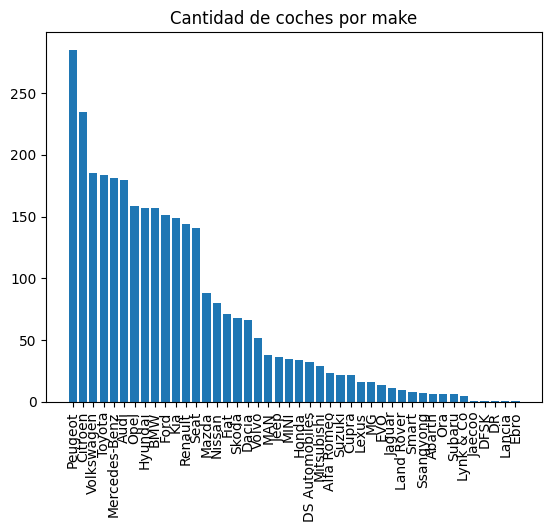

In [227]:
plt.bar(data['make'].value_counts().index, data['make'].value_counts().values)
plt.xticks(rotation=90)
plt.title('Cantidad de coches por make')
plt.show()

In [228]:
print(data['make'].value_counts())

make
Peugeot           285
Citroen           235
Volkswagen        185
Toyota            184
Mercedes-Benz     181
Audi              180
Opel              159
Hyundai           157
BMW               157
Ford              151
Kia               149
Renault           144
Seat              141
Mazda              88
Nissan             80
Fiat               71
Skoda              68
Dacia              66
Volvo              52
MAN                38
Jeep               36
MINI               35
Honda              34
DS Automobiles     32
Mitsubishi         29
Alfa Romeo         23
Suzuki             22
Cupra              22
Lexus              16
MG                 16
EVO                14
Jaguar             11
Land Rover         10
Smart               8
Ssangyong           7
Abarth              6
Ora                 6
Subaru              6
Lynk & Co           5
Jaecoo              1
DFSK                1
DR                  1
Lancia              1
Ebro                1
Name: count, dtype: int64


In [229]:
data.head()

,make,marca_id_x,version_id_catalogo,titulo_anuncio,registro,kms,cambio,combustible,cv,precio,version_id,modelo_id,clave_motor,nombre_completo,id_web,nombre_modelo,marca_id_y,nombre_marca
0,Kia,425,3457,kia cee'd 1.6 crdi,06/2014,17222,Manual,Diésel,128,12599,3458.0,694.0,1.6 CRDi,cee'd 1.6 CRDi,cee'd,cee'd,425.0,Kia
1,Kia,425,3554,kia sorento 1.6 tgdi plug-in hybrid,04/2024,32462,Automático,Híbrido,265,40999,3554.0,723.0,1.6 TGDI Plug-in Hybrid,Sorento 1.6 TGDI Plug-in Hybrid,Sorento,Sorento,425.0,Kia
2,Peugeot,670,6159,peugeot 3008 2.0 blue-hdi,07/2018,78068,Manual,Diésel,150,17299,6159.0,1127.0,2.0 Blue-HDi,3008 2.0 Blue-HDi,3008,3008,670.0,Peugeot
3,Mercedes-Benz,570,<NA>,mercedes-benz clase gla gla 250e,02/2024,19060,Automático,Híbrido,218,39999,4645.0,898.0,GLA 250e,GLA-Klasse GLA 250e,GLA-Klasse,Clase GLA,570.0,Mercedes-Benz
4,Citroen,190,1551,citroen c4 cactus 1.6 blue-hdi,10/2016,94982,Manual,Diésel,100,9399,1551.0,277.0,1.6 Blue-HDi,C4 Cactus 1.6 Blue-HDi,C4 Cactus,C4 Cactus,190.0,Citroen


In [230]:
data.drop(columns=['marca_id_x', 'version_id_catalogo', 'titulo_anuncio', 'version_id', 'modelo_id', 'nombre_completo', 'id_web', 'marca_id_y', 'nombre_marca'], inplace=True)
data.head()

,make,registro,kms,cambio,combustible,cv,precio,clave_motor,nombre_modelo
0,Kia,06/2014,17222,Manual,Diésel,128,12599,1.6 CRDi,cee'd
1,Kia,04/2024,32462,Automático,Híbrido,265,40999,1.6 TGDI Plug-in Hybrid,Sorento
2,Peugeot,07/2018,78068,Manual,Diésel,150,17299,2.0 Blue-HDi,3008
3,Mercedes-Benz,02/2024,19060,Automático,Híbrido,218,39999,GLA 250e,Clase GLA
4,Citroen,10/2016,94982,Manual,Diésel,100,9399,1.6 Blue-HDi,C4 Cactus


In [231]:
data = data.rename(columns={
    'cambio': 'gear_type',
    'combustible': 'fuel_type',
    'registro': 'registration',
    'cv': 'power',
    'precio': 'price',
    'clave_motor': 'version',
    'nombre_modelo': 'model'
})

In [232]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3114 entries, 0 to 3113
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   make          3114 non-null   str  
 1   registration  3114 non-null   str  
 2   kms           3114 non-null   int64
 3   gear_type     3114 non-null   str  
 4   fuel_type     3114 non-null   str  
 5   power         3114 non-null   int64
 6   price         3114 non-null   int64
 7   version       3026 non-null   str  
 8   model         3026 non-null   str  
dtypes: int64(3), str(6)
memory usage: 219.1 KB


In [233]:
df_makes_precio_medio = data.groupby(['make'])['price'].mean().reset_index()
df_makes_precio_medio.head()

,make,price
0,Abarth,17932.333333
1,Alfa Romeo,20799.000000
2,Audi,21241.777778
3,BMW,22238.490446
4,Citroen,11468.787234


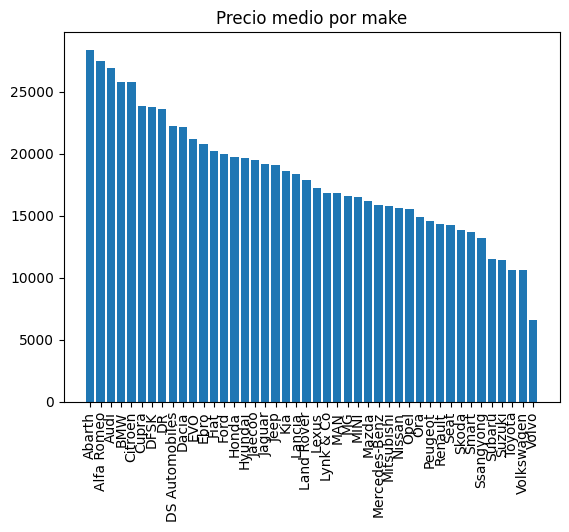

In [234]:
plt.bar(df_makes_precio_medio['make'], df_makes_precio_medio['price'].sort_values(ascending=False))
plt.xticks(rotation=90)
plt.title('Precio medio por make')
plt.show()

In [235]:
df_makes_kms_medios = data.groupby(['make'])['kms'].mean().reset_index()

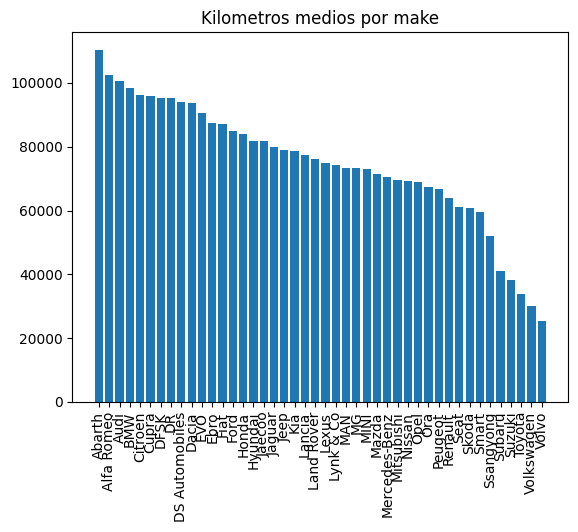

In [236]:
plt.bar(df_makes_kms_medios['make'], df_makes_kms_medios['kms'].sort_values(ascending=False))
plt.xticks(rotation=90)
plt.title('Kilometros medios por make')
plt.show()

In [237]:
data[data['make'] == 'Abarth']

,make,registration,kms,gear_type,fuel_type,power,price,version,model
20,Abarth,03/2018,38445,Manual,Gasolina,145,15999,1.4 Turbo,500
1422,Abarth,09/2020,90134,Manual,Gasolina,145,14699,1.4 Turbo,595
2501,Abarth,11/2022,31198,Manual,Gasolina,179,21599,1.4 Turbo,695
2609,Abarth,08/2024,22446,Manual,Gasolina,179,24899,1.4 Turbo,500
2675,Abarth,05/2019,100392,Automático,Gasolina,180,15499,1.4,595C
2740,Abarth,05/2019,82228,Manual,Gasolina,160,14899,1.4,595


In [238]:
data['registration'] = pd.to_datetime(data['registration'], format='%m/%Y')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3114 entries, 0 to 3113
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   make          3114 non-null   str           
 1   registration  3114 non-null   datetime64[us]
 2   kms           3114 non-null   int64         
 3   gear_type     3114 non-null   str           
 4   fuel_type     3114 non-null   str           
 5   power         3114 non-null   int64         
 6   price         3114 non-null   int64         
 7   version       3026 non-null   str           
 8   model         3026 non-null   str           
dtypes: datetime64[us](1), int64(3), str(5)
memory usage: 219.1 KB


In [239]:
df_groupby_model = data.groupby(['model', 'make']).agg({
    'kms': 'mean', 
    'power': 'mean', 
    'registration': 'mean', 
    'price': 'mean'
}).reset_index()
df_groupby_model

,model,make,kms,power,registration,price
0,01,Lynk & Co,68843.000000,261.000000,2022-12-12 19:12:00.000000,22139.000000
1,108,Peugeot,53475.571429,71.714286,2019-04-05 17:08:34.285714,9056.142857
2,2,Mazda,60646.400000,92.200000,2019-12-31 04:48:00.000000,13999.000000
3,2008,Peugeot,70269.750000,114.616667,2019-09-12 11:36:00.000000,12780.666667
4,208,Peugeot,72206.042553,93.702128,2019-07-03 08:40:51.063829,10116.021277
...,...,...,...,...,...,...
305,i40,Hyundai,130029.000000,135.000000,2014-04-01 00:00:00.000000,8999.000000
306,ix20,Hyundai,67940.000000,125.000000,2016-07-01 00:00:00.000000,11399.000000
307,ix35,Hyundai,124390.750000,120.000000,2014-11-03 21:00:00.000000,11486.500000
308,pro_cee'd,Kia,134385.000000,137.500000,2017-12-31 12:00:00.000000,11299.000000


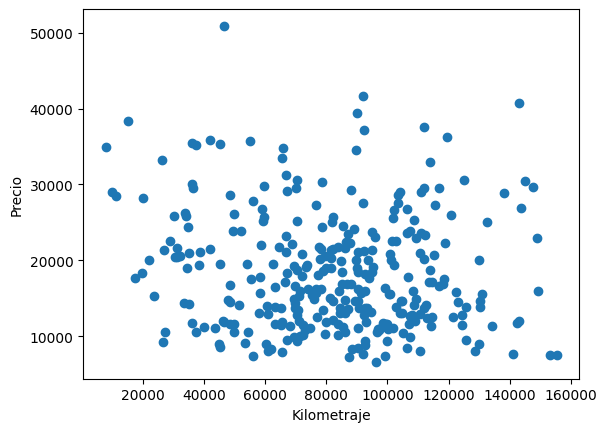

In [240]:
plt.scatter(x=df_groupby_model['kms'], y=df_groupby_model['price'])
plt.xlabel('Kilometraje')
plt.ylabel('Precio')
plt.show()

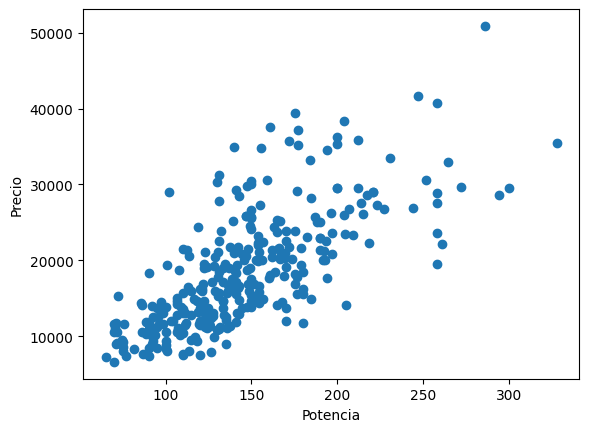

In [241]:
plt.scatter(x=df_groupby_model['power'], y=df_groupby_model['price'])
plt.xlabel('Potencia')
plt.ylabel('Precio')
plt.show()

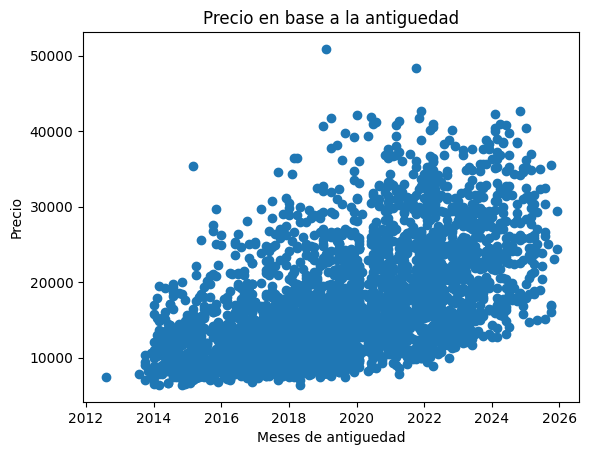

In [242]:
plt.scatter(x=data['registration'], y=data['price'])
plt.title('Precio en base a la antiguedad')
plt.xlabel('Meses de antiguedad')
plt.ylabel('Precio')
plt.show()

In [243]:
# Transformamos las columnas categoricas
le_gear = LabelEncoder()
le_fuel = LabelEncoder()

df_final['gear_type'] = le_gear.fit_transform(df_final['gear_type']) + 1
df_final['fuel_type'] = le_fuel.fit_transform(df_final['fuel_type']) + 1

# Copiamos el dataset para exportarlo a la bbdd
df_export = df_final.copy()

hoy = pd.Timestamp.now()
df_final['antiguedad_meses'] = ((hoy.year - data['registration'].dt.year) * 12 + (hoy.month - data['registration'].dt.month))

# Eliminamos la columna original de fecha porque el modelo no la entiende
df_final = df_final.drop(columns=['registration'])


In [244]:
df_final.head()

,kms,gear_type,fuel_type,power,price,version,model,make,antiguedad_meses
0,17222,3,1,128,12599,3458,694,425,144
1,32462,1,3,265,40999,3554,723,425,26
2,78068,3,1,150,17299,6159,1127,670,95
3,19060,1,3,218,39999,4645,898,570,28
4,94982,3,1,100,9399,1551,277,190,116


Text(0.5, 1.0, 'Outliers de Kilómetros')

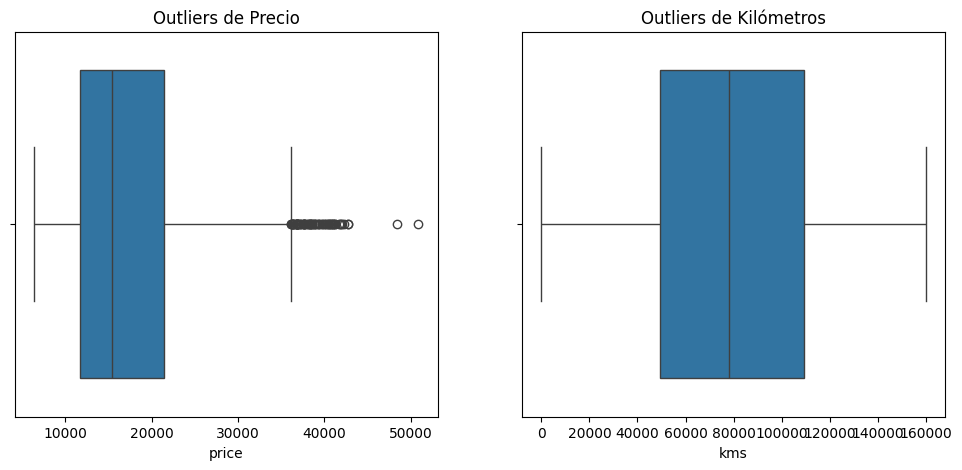

In [245]:
plt.figure(figsize=(12, 5))

# Gráfico para Precio
plt.subplot(1, 2, 1)
sns.boxplot(x=data['price'])
plt.title('Outliers de Precio')

# Gráfico para kms
plt.subplot(1, 2, 2)
sns.boxplot(x=data['kms'])
plt.title('Outliers de Kilómetros')

In [246]:
#  Vemos el porcentaje de outliers
print(df_final[df_final['price'] > 36000]['price'].count())
total_outliers = len(df_final[df_final['price'] > 36000])
porcentaje = (total_outliers / len(df_final)) * 100
print(f"Porcentaje de outliers en price: {porcentaje}")

63
Porcentaje de outliers en price: 2.081956378056841


In [247]:
df_final = df_final[df_final['price'] <= 36000]

Text(0.5, 1.0, 'Outliers de Precio')

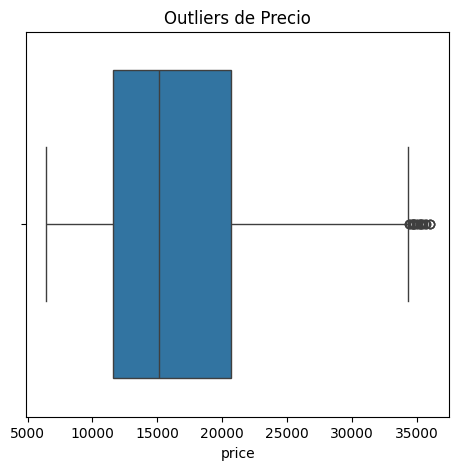

In [248]:
plt.figure(figsize=(12, 5))

# Gráfico para Precio
plt.subplot(1, 2, 1)
sns.boxplot(x=df_final['price'])
plt.title('Outliers de Precio')

In [249]:
# REcogemos los datos que nos interesan que hemos sacado con la investigación
df_clean = df_export[df_export['price'] <= 36000]

In [250]:
orden_df = [
    'make',
    'model',
    'version',
    'gear_type',
    'fuel_type',
    'power',
    'kms',
    'registration',
    'price'
]

In [251]:
df_clean = df_clean[orden_df]
df_clean.head()

,make,model,version,gear_type,fuel_type,power,kms,registration,price
0,425,694,3458,3,1,128,17222,06/2014,12599
2,670,1127,6159,3,1,150,78068,07/2018,17299
4,190,277,1551,3,1,100,94982,10/2016,9399
5,790,1235,6913,3,2,116,7628,03/2025,22999
6,830,1320,7273,1,2,83,30872,09/2023,16999


In [252]:
# División de datos
X = df_final.drop(columns='price')
y = df_final['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [253]:
X.info()

<class 'pandas.DataFrame'>
Index: 2963 entries, 0 to 3113
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   kms               2963 non-null   int64
 1   gear_type         2963 non-null   int64
 2   fuel_type         2963 non-null   int64
 3   power             2963 non-null   int64
 4   version           2963 non-null   Int64
 5   model             2963 non-null   Int64
 6   make              2963 non-null   Int64
 7   antiguedad_meses  2963 non-null   int32
dtypes: Int64(3), int32(1), int64(4)
memory usage: 205.4 KB


In [254]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
import numpy as np

In [255]:
# Entrenamiento del modelo
# Como es calcular un precio, usaremos una regresión
model = XGBRegressor(n_estimators=450, learning_rate=0.07, max_depth=5, random_state=42)
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [256]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
# Calcular el error relativo
error_relativo = (mae / df_final['price'].mean()) * 100

print(f"MAE (Error Absoluto Medio): {mae:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"Error relativo: {error_relativo}")

MAE (Error Absoluto Medio): 1363.27
RMSE (Raíz del Error Cuadrático Medio): 1951.19
R2 Score: 0.9145
Error relativo: 8.167828208424147


In [257]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

resultados = cross_val_score(model, X, y, cv=skf)

print(f"Resultados de la validación cruzada: {resultados}")
print(f"Media de la validación cruzada: {resultados.mean():.4f}")
print(f"Desviación estandard de la validación cruzada: {resultados.std():.4f}")

c:\Javi\Proyectos\IberiaDriveInsghts\venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Resultados de la validación cruzada: [0.92473382 0.91709608 0.89067829 0.92520851 0.91788542 0.92327201
 0.93584949 0.92638886 0.88812178 0.91476458]
Media de la validación cruzada: 0.9164
Desviación estandard de la validación cruzada: 0.0146


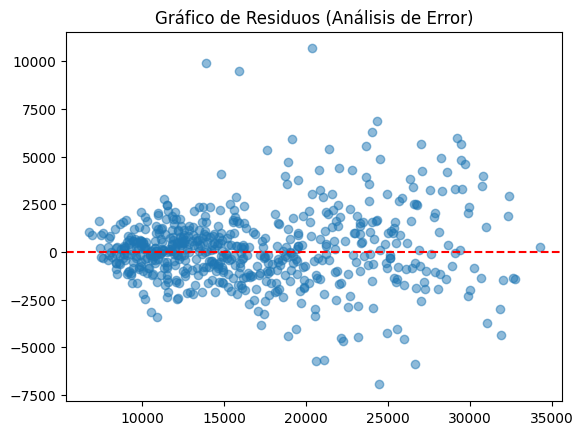

In [258]:
error = y_test - model.predict(X_test)
plt.scatter(model.predict(X_test), error, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Gráfico de Residuos (Análisis de Error)')
plt.show()

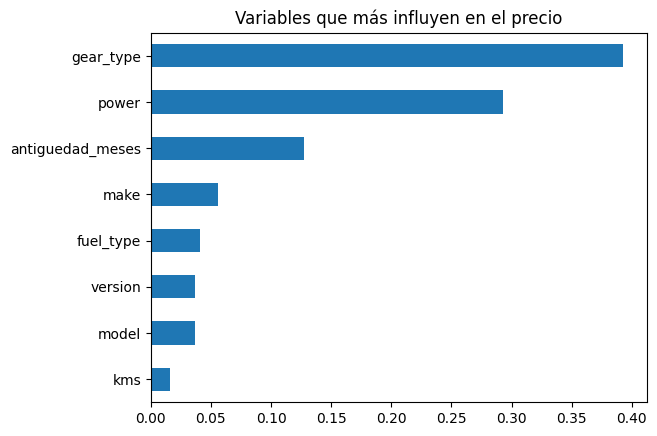

In [259]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh')
plt.title('Variables que más influyen en el precio')
plt.show()

In [260]:
# Para acabar de perfeccionar el modelo vamos a hacer un GridSearchCV
model = XGBRegressor(random_state=42)

# Definimos los hiperparámetros a probar
param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

In [261]:
# Configuramos el K-Fold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Configuramos el GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=skf,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

# Ejecutamos el entrenamiento
grid_search.fit(X_train, y_train)

Fitting 10 folds for each of 54 candidates, totalling 540 fits


c:\Javi\Proyectos\IberiaDriveInsghts\venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 300, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 :

In [262]:
print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor score (MAE): {-grid_search.best_score_:.2f}")

# El modelo ya está ajustado con los mejores parámetros automáticamente
best_model = grid_search.best_estimator_

Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}
Mejor score (MAE): 1399.56


In [263]:
y_pred_final = best_model.predict(X_test)

print(f"MAE en test: {mean_absolute_error(y_test, y_pred_final):.2f}")
print(f"R2 Score en test: {r2_score(y_test, y_pred_final):.4f}")
print(f"RMSE en test: {np.sqrt(mean_squared_error(y_test, y_pred_final)):.2f}")
print(f"Error relativo en test: {(mean_absolute_error(y_test, y_pred_final) / df_final['price'].mean()) * 100:.2f}")

MAE en test: 1321.33
R2 Score en test: 0.9216
RMSE en test: 1868.64
Error relativo en test: 7.92


In [264]:
# Guardar modelo
if not os.path.exists('../ai_models'):
    os.makedirs('../ai_models')

if not os.path.exists('../ai_models/compra_coches'):
    os.makedirs('../ai_models/compra_coches')

# Guardar modelo
joblib.dump(best_model, '../ai_models/compra_coches/modelo_compra_coches_iberia.pkl')

# Guardr lista de columnas de los datos a entrenar
encoders = {
    'le_gear': le_gear,
    'le_fuel': le_fuel,
    'features_names': df_final.drop(columns=['price']).columns.tolist()
}
joblib.dump(encoders, '../ai_models/compra_coches/transformadores.pkl')

['../ai_models/compra_coches/transformadores.pkl']

In [265]:
df_clean['is_prediction'] = False
df_clean['rep_id'] = 1
df_clean['price_base'] = df_clean['price']
df_clean['status'] = "success"
df_clean['dmgs_detectados'] = "Ninguno"

df_clean.to_csv('../datasets/coches_clean.csv', index=False)

In [266]:
fuel_bbdd = {
    'id': range(1, len(le_fuel.classes_) + 1),
    'nombre': le_fuel.classes_
}
pd.DataFrame(fuel_bbdd).to_csv('../datasets/seed_fuel_types.csv', index=False)

In [267]:
fuel_bbdd = {
    'id': range(1, len(le_gear.classes_) + 1),
    'nombre': le_gear.classes_
}
pd.DataFrame(fuel_bbdd).to_csv('../datasets/seed_gear_types.csv', index=False)

In [268]:
df_marcas = df_marcas.rename(columns={
    'marca_id': 'id',
    'nombre_marca': 'nombre'
})

df_modelos = df_modelos.rename(columns={
    'modelo_id': 'id',
    'nombre_modelo': 'nombre',
    'marca_id': 'id_marca',
})

df_modelos = df_modelos.drop('id_web', axis=1)

df_versiones = df_versiones.rename(columns={
    'version_id': 'id',
    'clave_motor': 'nombre',
    'modelo_id': 'id_modelo',
})

df_versiones = df_versiones.drop('nombre_completo', axis=1)

In [269]:
df_versiones.to_csv('../datasets/seed_versiones_bbdd.csv', index=False)
df_modelos.to_csv('../datasets/seed_modelos_bbdd.csv', index=False)
df_marcas.to_csv('../datasets/seed_marcas_bbdd.csv', index=False)